In [1]:
%cp -r ../resources .

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from Astrid.data_processing import get_weights
from Astrid.config import MC_FILENAMES, PARAMS, PARAMETER_NAMES
import data_loader
import weighter
import binning
import gc

In [4]:
# Define your energy range (in GeV)
energy_bins = np.logspace(4, 7, 3 * 20 + 1)  # 10 TeV to 10 PeV
energy_bins_plotting = np.logspace(4, 7, 20)  # 10 TeV to 10 PeV
livetime = 227708167.68  # HESE livetime in seconds
params_dict = dict(zip(PARAMETER_NAMES, PARAMS))


In [5]:
mc = data_loader.load_mc(MC_FILENAMES, emin=energy_bins[0], emax=energy_bins[-1])
data = data_loader.load_data("/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/resources/data/HESE_data.json", emin=energy_bins[0], emax=energy_bins[-1])

In [6]:
weight_maker = weighter.Weighter(mc)

Testing the weights with all parameters as best fit values

In [7]:
weights_tot = weight_maker.get_weights(livetime, params_dict.keys(), params_dict.values())
weights_tot = weights_tot[0]
gc.collect()
print(weights_tot)
print(len(weights_tot))

[3.37888874e-05 1.12083736e-04 9.63237834e-05 ... 2.79940289e-03
 1.65678384e-01 1.22073749e-03]
819370


In [8]:
total_events = np.sum(weights_tot)
print('total_events', total_events)

total_events 176.65735246238756


In [9]:
p_copy = params_dict.copy()

p_copy["conv_norm"] = 0.0
p_copy["prompt_norm"] = 0.0
p_copy["muon_norm"] = 0.0

print(p_copy)
    
weights_astro = weight_maker.get_weights(livetime, p_copy.keys(), p_copy.values())
astro_weights = weights_astro[0]
gc.collect()
print('astro_weights', astro_weights)
total_astro_events = np.sum(astro_weights)
print('total_astro_events', total_astro_events)


{'cr_delta_gamma': np.float64(-0.05309302), 'nunubar_ratio': np.float64(0.99815326), 'anisotropy_scale': np.float64(1.000683), 'astro_gamma': np.float64(2.0), 'astro_norm': np.float64(6.36488608), 'conv_norm': 0.0, 'epsilon_dom': np.float64(0.95192328), 'epsilon_head_on': np.float64(-0.0548763), 'muon_norm': 0.0, 'kpi_ratio': np.float64(1.00013744), 'prompt_norm': 0.0}
astro_weights [3.37191093e-05 1.11825398e-04 9.48292391e-05 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
total_astro_events 140.18976278817902


In [10]:
p_copy = params_dict.copy()

p_copy["conv_norm"] = 0.0
p_copy["prompt_norm"] = 0.0
p_copy["astro_norm"] = 0.0

    
weights_muon = weight_maker.get_weights(livetime, p_copy.keys(), p_copy.values())
muon_weights = weights_muon[0]
gc.collect()
print('muon_weights', muon_weights)
total_muon_events = np.sum(muon_weights)
print('total_muon_events', total_muon_events)


muon_weights [0.         0.         0.         ... 0.0027994  0.16567838 0.00122074]
total_muon_events 15.087574185347643


In [11]:
p_copy = params_dict.copy()

p_copy["prompt_norm"] = 0.0
p_copy["muon_norm"] = 0.0
p_copy["astro_norm"] = 0.0

    
weights_conv = weight_maker.get_weights(livetime, p_copy.keys(), p_copy.values())
conv_weights = weights_conv[0]
gc.collect()
print('conv_weights', conv_weights)
total_conv_events = np.sum(conv_weights)
print('total_conv_events', total_conv_events)

conv_weights [6.97780992e-08 2.58337895e-07 1.49454428e-06 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
total_conv_events 21.3800154888609


In [15]:
p_copy = params_dict.copy()


p_copy["astro_norm"] = 0.0

    
weights_background = weight_maker.get_weights(livetime, p_copy.keys(), p_copy.values())
background_weights = weights_background[0]
gc.collect()
print('background_weights', background_weights)
total_background_events = np.sum(background_weights)
print('total_background_events', total_background_events)

background_weights [6.97780992e-08 2.58337895e-07 1.49454428e-06 ... 2.79940289e-03
 1.65678384e-01 1.22073749e-03]
total_background_events 36.46758967420854


In [12]:
conv_total_events = np.sum(conv_weights)
print('conv_total_events', conv_total_events)

#prompt_total_events = np.sum(prompt_weights)
#print('prompt_total_events', prompt_total_events)

muon_total_events = np.sum(muon_weights)
print('muon_total_events', muon_total_events)

astro_total_events = np.sum(astro_weights)
print('astro_total_events', astro_total_events)

total_events = np.sum(weights_tot)
print('total_events', total_events)

conv_total_events 21.3800154888609
muon_total_events 15.087574185347643
astro_total_events 140.18976278817902
total_events 176.65735246238756


In [13]:
gc.collect()

conv_total_events = np.sum(conv_weights)
print('conv_total_events', conv_total_events)

muon_total_events = np.sum(muon_weights)
print('muon_total_events', muon_total_events)

astro_total_events = np.sum(astro_weights)
print('astro_total_events', astro_total_events)

total_events = np.sum(weights_tot)
print('total_events', total_events)

#assert total_events == conv_total_events + muon_total_events + astro_total_events

conv_total_events 21.3800154888609
muon_total_events 15.087574185347643
astro_total_events 140.18976278817902
total_events 176.65735246238756


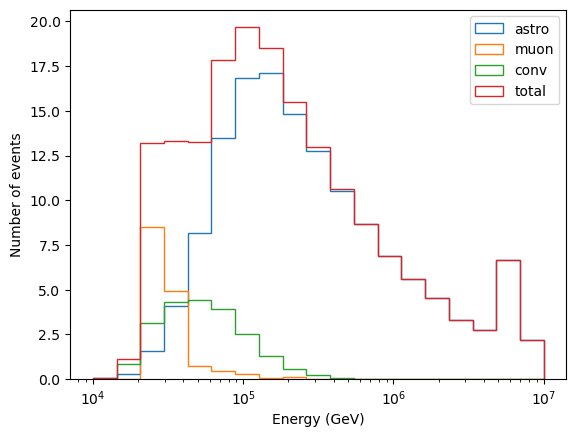

In [14]:
plt.hist(mc['recoDepositedEnergy'], bins=energy_bins_plotting, weights=astro_weights, label='astro', histtype='step')
plt.hist(mc['recoDepositedEnergy'], bins=energy_bins_plotting, weights=muon_weights, label='muon', histtype='step')
plt.hist(mc['recoDepositedEnergy'], bins=energy_bins_plotting, weights=conv_weights, label='conv', histtype='step')
plt.hist(mc['recoDepositedEnergy'], bins=energy_bins_plotting, weights=weights_tot, label='total', histtype='step')
plt.xscale('log')
plt.xlabel('Energy (GeV)')
plt.ylabel('Number of events')
plt.legend()
plt.show()